In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix
                            , roc_auc_score)

import warnings
warnings.filterwarnings('ignore')                       

In [10]:
# Load Titanic dataset directly from URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
print(df.head())
print(df.info())
print(df.describe())

Shape: (891, 12)
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-

Survived Count
891

 Survival rate: 38.38%

 NULL values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


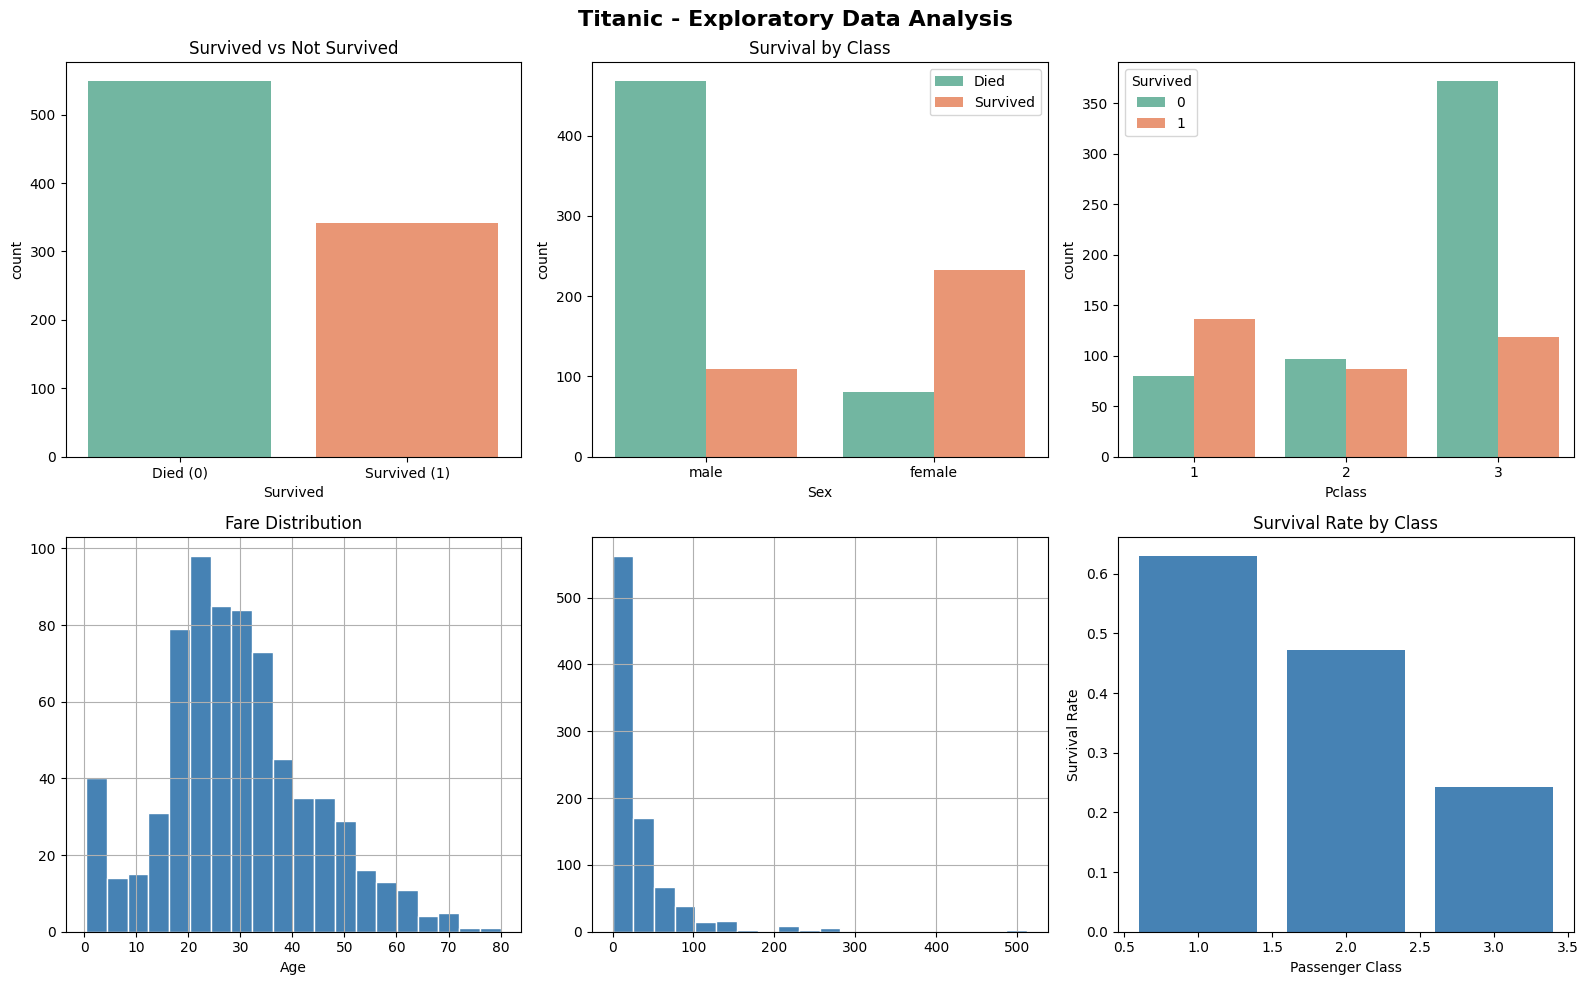

In [16]:
#Exploring the Data

print('Survived Count')
print(df['Survived'].count())
print(f'\n Survival rate: {df['Survived'].mean():.2%}')

print('\n NULL values')
print(df.isnull().sum())

fig, axes = plt.subplots(2,3, figsize = (16,10))
fig.suptitle('Titanic - Exploratory Data Analysis', fontsize=16
             , fontweight = 'bold')

# Survival Count
sns.countplot(data = df, x = 'Survived', palette = 'Set2', ax = axes[0,0])
axes[0,0].set_title('Survived vs Not Survived')
axes[0,0].set_xticklabels(['Died (0)', 'Survived (1)'])

# Survival by gender
sns.countplot(data=df, x='Sex', hue='Survived', palette = 'Set2', ax = axes[0,1])
axes[0,1].set_title('Survival by Gender')
axes[0,1].legend(['Died', 'Survived'])

# Survival by class
sns.countplot(data=df, x='Pclass', hue='Survived', palette = 'Set2', ax = axes[0,2])
axes[0,1].set_title('Survival by Class')
axes[0,1].legend(['Died', 'Survived'])

# Age distribution
df['Age'].hist(bins=20, ax = axes[1,0], color = 'steelblue', edgecolor='white')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')

# Fare distribution
df['Fare'].hist(bins=20, ax = axes[1,1], color = 'steelblue', edgecolor='white')
axes[1,0].set_title('Fare Distribution')

# Survival rate by class
survival_by_class = df.groupby('Pclass')['Survived'].mean()

axes[1,2].bar(survival_by_class.index, survival_by_class.values, color = 'steelblue')
axes[1,2].set_title('Survival Rate by Class')
axes[1,2].set_xlabel('Passenger Class')
axes[1,2].set_ylabel('Survival Rate')

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Clean and Engineer Features

# Work on a copy
data = df.copy()

# Drop columns that don't help prediction
data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Fill missing Age with median
data['Age'].fillna(data['Age'].median(), inplace=True)

# Fill missing Embarked with mode
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Encode Sex — male=1, female=0
data['Sex'] = LabelEncoder().fit_transform(data['Sex'])

# Encode Embarked — S=2, Q=1, C=0
data['Embarked'] = LabelEncoder().fit_transform(data['Embarked'])

# Feature Engineering
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

# Fill missing Age values properly
data['Age'] = pd.to_numeric(data['Age'], errors='coerce')
data['Age'] = data['Age'].fillna(data['Age'].median())

# Create AgeGroup safely
data['AgeGroup'] = pd.cut(
    data['Age'],
    bins=[-1, 12, 18, 35, 60, 200],
    labels=False,
    include_lowest=True
)

# Fill any remaining NaN values
data['AgeGroup'] = data['AgeGroup'].fillna(0)

# Convert to integer
data['AgeGroup'] = data['AgeGroup'].astype(int)

print("After cleaning:")
print(data.head())

print("\nNull values:")
print(data.isnull().sum())

print("\nData Types:")
print(data.dtypes)

After cleaning:
   Survived  Pclass  Sex  ...  FamilySize  IsAlone  AgeGroup
0         0       3    1  ...           2        0         2
1         1       1    0  ...           2        0         3
2         1       3    0  ...           1        1         2
3         1       1    0  ...           2        0         2
4         0       3    1  ...           1        1         2

[5 rows x 11 columns]

Null values:
Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
AgeGroup      0
dtype: int64

Data Types:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked        int64
FamilySize      int64
IsAlone         int64
AgeGroup        int64
dtype: object


In [36]:
# Preparing X & y

X = data.drop('Survived', axis=1) # Everything Except the label 'Survived'
y = data['Survived'] # The label 'Survived'

print(f'Features: {list(X.columns)}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Survival rate: {y.mean():.2%}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2
                    , random_state= 42, stratify=y)

print(f'\nTrain: {len(X_train)} | Test: {len(X_test)}')
print(f'Train survival rate: {y_train.mean():.2%}')
print(f'Test survival rate: {y_test.mean():.2%}')

# Scale features for Logistic Regression

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.fit_transform(X_test)

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'AgeGroup']
X shape: (891, 10)
y shape: (891,)
Survival rate: 38.38%

Train: 712 | Test: 179
Train survival rate: 38.34%
Test survival rate: 38.55%


In [37]:
# Train 3 Models

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression
    if name == 'Logistic Regression':
        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)
        y_prob = model.predict_proba(X_test_s)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results[name] = {'accuracy': acc, 'auc': auc, 'model': model, 'y_pred': y_pred}

    print(f"\n=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC:  {auc:.4f}")

# Summary table
print("\n=== Model Comparison ===")
for name, res in results.items():
    print(f"{name:25s} | Accuracy: {res['accuracy']:.4f} | AUC: {res['auc']:.4f}")


=== Logistic Regression ===
Accuracy: 0.8045
ROC-AUC:  0.8602

=== Decision Tree ===
Accuracy: 0.7598
ROC-AUC:  0.8018

=== Random Forest ===
Accuracy: 0.8212
ROC-AUC:  0.8335

=== Model Comparison ===
Logistic Regression       | Accuracy: 0.8045 | AUC: 0.8602
Decision Tree             | Accuracy: 0.7598 | AUC: 0.8018
Random Forest             | Accuracy: 0.8212 | AUC: 0.8335


Random Forests - Detailed Report 

              precision    recall  f1-score   support

        Died       0.85      0.86      0.86       110
    Survived       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



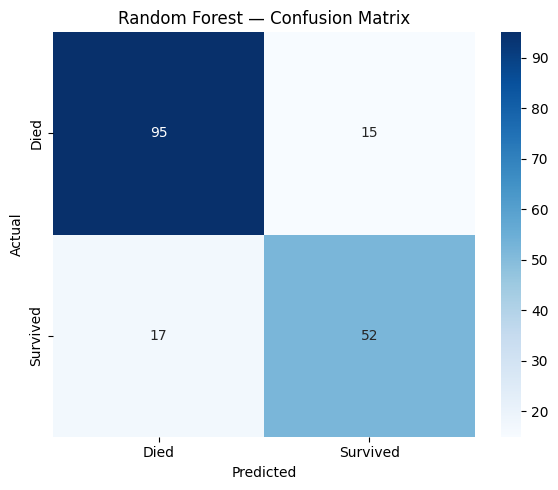


True Negatives  (correctly predicted Died):     95
False Positives (predicted Survived, actually Died): 15
False Negatives (predicted Died, actually Survived): 17
True Positives  (correctly predicted Survived): 52


In [38]:
# Detailed Evaluation of Best Model

# Random Forest is usually best — let's evaluate it in detail

best_model = results['Random Forest']['model']
y_pred_best = results['Random Forest']['y_pred']

print('Random Forests - Detailed Report \n')
print(classification_report(y_test, y_pred_best, target_names=['Died', 'Survived']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize = (6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Died', 'Survived'],
            yticklabels=['Died', 'Survived'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Read the confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly predicted Died):     {tn}")
print(f"False Positives (predicted Survived, actually Died): {fp}")
print(f"False Negatives (predicted Died, actually Survived): {fn}")
print(f"True Positives  (correctly predicted Survived): {tp}")

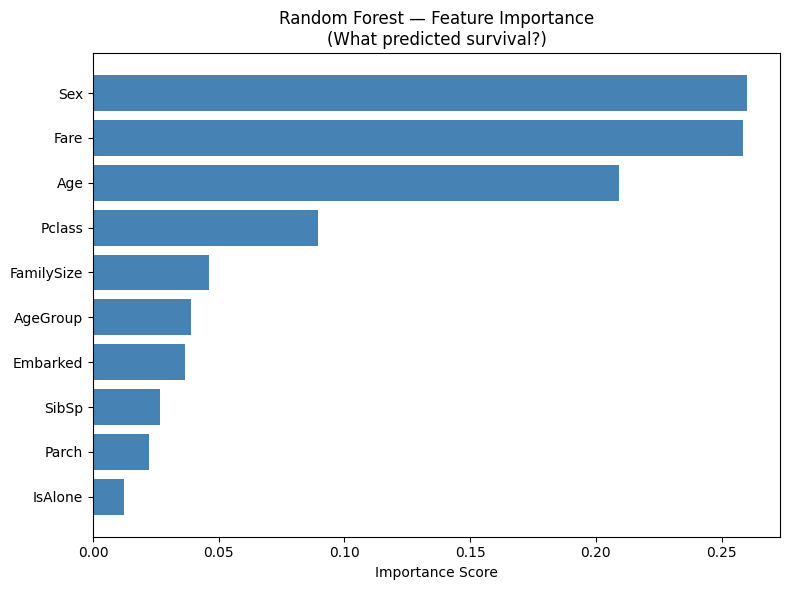

Most important features:
      feature  importance
1         Sex    0.260221
5        Fare    0.258649
2         Age    0.209012
0      Pclass    0.089617
7  FamilySize    0.046021
9    AgeGroup    0.039008
6    Embarked    0.036636
3       SibSp    0.026611
4       Parch    0.022088
8     IsAlone    0.012137


In [39]:
# Feature Importance

# Which features matter most for survival?
feature_names = list(X.columns)
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(feat_df['feature'], feat_df['importance'], color='steelblue')
plt.title('Random Forest — Feature Importance\n(What predicted survival?)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Most important features:")
print(feat_df.sort_values('importance', ascending=False))

In [40]:
# Cross Validation

# Cross validation gives more reliable accuracy estimate

rf = RandomForestClassifier(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf,X,y, cv = 5, scoring='accuracy')

print('5-Fold Cross Validation')
print(f'Scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f}')
print(f'Std: {cv_scores.std():.4f}')

print(f"95% CI: ({cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f})")

5-Fold Cross Validation
Scores: [0.7821 0.8146 0.8483 0.7753 0.8146]
Mean: 0.8070
Std: 0.0263
95% CI: (0.7545, 0.8595)


In [41]:
# Predict New Passenger

# Would YOU have survived the Titanic
new_passenger = pd.DataFrame({
    'Pclass':     [3],        # 3rd class
    'Sex':        [1],        # male = 1
    'Age':        [19],       # age 19
    'SibSp':      [0],        # no siblings
    'Parch':      [0],        # no parents
    'Fare':       [8.05],     # cheap ticket
    'Embarked':   [2],        # Southampton
    'FamilySize': [1],        # alone
    'IsAlone':    [1],        # yes alone
    'AgeGroup':   [2],        # young adult
})

survival_prob = best_model.predict_proba(new_passenger)[0][1]
prediction    = best_model.predict(new_passenger)[0]

print("=== Passenger Prediction ===")
print(f"Class: 3rd | Sex: Male | Age: 19 | Alone")
print(f"\nSurvival Probability: {survival_prob:.2%}")
print(f"Prediction: {'SURVIVED' if prediction == 1 else 'DID NOT SURVIVE'}")

# Try a different passenger
rich_woman = pd.DataFrame({
    'Pclass': [1], 'Sex': [0], 'Age': [30], 'SibSp': [1],
    'Parch': [0], 'Fare': [100], 'Embarked': [0],
    'FamilySize': [2], 'IsAlone': [0], 'AgeGroup': [2]
})
prob2 = best_model.predict_proba(rich_woman)[0][1]
print(f"\n1st Class Woman, Age 30, With Husband:")
print(f"Survival Probability: {prob2:.2%}")
print(f"Prediction: {'SURVIVED' if best_model.predict(rich_woman)[0] == 1 else 'DID NOT SURVIVE'}")

=== Passenger Prediction ===
Class: 3rd | Sex: Male | Age: 19 | Alone

Survival Probability: 37.77%
Prediction: DID NOT SURVIVE

1st Class Woman, Age 30, With Husband:
Survival Probability: 100.00%
Prediction: SURVIVED
